# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [1]:
import pandas as pd
import seaborn as sns

penguins = sns.load_dataset("penguins")
print(penguins.head())

penguins = penguins.dropna()
penguins = pd.get_dummies(penguins, columns=["species","island","sex"], drop_first=True)


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on a training dataset subset of the entire dataset:

* Four different models, each containing a different set of predictor variables

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

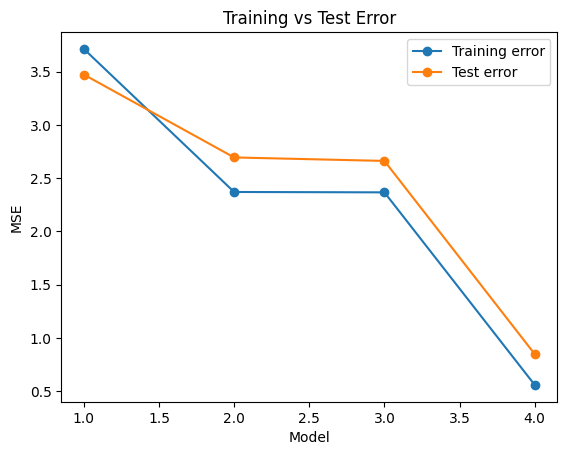

Train MSE: [3.7126330932428155, 2.369381637338261, 2.365820305543936, 0.5576486185394838]
Test MSE: [3.4718688809450082, 2.6937234820025084, 2.6608669830974576, 0.8471123519910406]


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

penguins = sns.load_dataset("penguins").dropna()
penguins = pd.get_dummies(penguins, columns=["species","island","sex"], drop_first=True)

y = penguins["bill_depth_mm"]
X = penguins.drop(columns="bill_depth_mm")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

m1 = LinearRegression().fit(X_train[["bill_length_mm"]], y_train)
m2 = LinearRegression().fit(X_train[["bill_length_mm","flipper_length_mm"]], y_train)
m3 = LinearRegression().fit(X_train[["bill_length_mm","flipper_length_mm","body_mass_g"]], y_train)
m4 = LinearRegression().fit(X_train, y_train)

train_mse = [
    mean_squared_error(y_train, m1.predict(X_train[["bill_length_mm"]])),
    mean_squared_error(y_train, m2.predict(X_train[["bill_length_mm","flipper_length_mm"]])),
    mean_squared_error(y_train, m3.predict(X_train[["bill_length_mm","flipper_length_mm","body_mass_g"]])),
    mean_squared_error(y_train, m4.predict(X_train))
]

test_mse = [
    mean_squared_error(y_test, m1.predict(X_test[["bill_length_mm"]])),
    mean_squared_error(y_test, m2.predict(X_test[["bill_length_mm","flipper_length_mm"]])),
    mean_squared_error(y_test, m3.predict(X_test[["bill_length_mm","flipper_length_mm","body_mass_g"]])),
    mean_squared_error(y_test, m4.predict(X_test))
]

plt.plot([1,2,3,4], train_mse, marker="o", label="Training error")
plt.plot([1,2,3,4], test_mse, marker="o", label="Test error")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.title("Training vs Test Error")
plt.legend()
plt.show()

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)


Model 1 underfits since its too simple and has high training and test error.
Model 4 fits best — it gives the lowest test MSE (= 0.85) after including all predictors.
Adding more variables helped lower error without causing overfitting, so Model 4 gives the best overall performance.